In [86]:
import numpy as np
import matplotlib.pyplot as plt

# physical properties
rho   = 1000.0            # water density kg/m³
mu    = 1.0e-3            # viscosity Pa·s
k     = 1.0e-12           # permeability m²
g     = 9.81              # gravitation acceleration rate m/s²

# hydraulic conductivity
K = rho * g * k / mu
print("K = ", K, " m/s ")

K =  9.81e-06  m/s 


In [87]:
# parameters domain 1-D
N   = 4
N2  = 1000
Lx  = 1.0              # m
dx  = Lx / N

T = 2.0 * K / dx # the transmissibility of internal cells 

# homogeneous aquifer so left and right are the same

TL = np.full(N, T)     # transmissibility of the face to the left of cell i
TR = np.full(N, T)     # transmissibility of the face to the right of cell i

# coeffient martix
diag_central = TL + TR # main diagonal of martix (total entering and leaving the cell)

sub_diag = -TL[1:]          # transmissibilities of the cells faces left of cell 2 
sup_diag = -TR[:-1]         # transmissibilities of the cells faces right of cell 1

# full matrix
Tmatrix = np.diag(diag_central) + np.diag(sub_diag, k=-1) + np.diag(sup_diag, k=1)

print (Tmatrix)


[[ 1.5696e-04 -7.8480e-05  0.0000e+00  0.0000e+00]
 [-7.8480e-05  1.5696e-04 -7.8480e-05  0.0000e+00]
 [ 0.0000e+00 -7.8480e-05  1.5696e-04 -7.8480e-05]
 [ 0.0000e+00  0.0000e+00 -7.8480e-05  1.5696e-04]]


In [88]:
# Boundary conditions
u_in = 0.001       # Darcy velocity left Neumann m/s
h_R  = 1.0         # head at the right boundary (Dirichlet)

#right-hand side vector
b = np.zeros(N)
b[0] = TL[0] * u_in #left
b[-1] = TR[-1] * h_R #right
print("Right-hand side vector", b)

#hydraulic heads (numerical)
h = np.linalg.solve(Tmatrix, b)
print("Hydraulic heads:", h)


Right-hand side vector [7.848e-08 0.000e+00 0.000e+00 7.848e-05]
Hydraulic heads: [0.2008 0.4006 0.6004 0.8002]


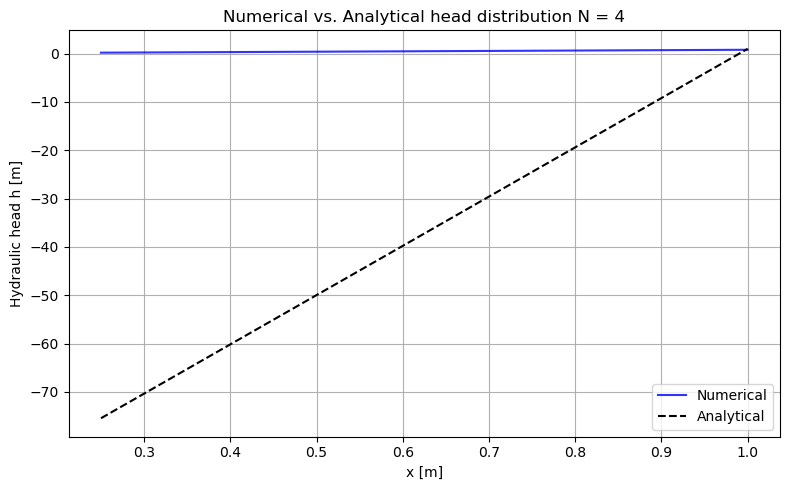

In [89]:
#plot hydraulic-head distribution with the analytical solution
h_num = np.linalg.solve(Tmatrix, b)

x_centres = (np.arange(1, N + 1)) * dx
h_ana = h_R - (u_in / K) * (1.0 - x_centres)

plt.figure(figsize=(8,5))
plt.plot(x_centres, h_num, 'b-', alpha=0.8, label='Numerical')
plt.plot(x_centres, h_ana, 'k--', label='Analytical')
plt.xlabel('x [m]')
plt.ylabel('Hydraulic head h [m]')
plt.title('Numerical vs. Analytical head distribution N = 4')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
# derived analytical solution for hydraulic head
"""
∇ * (-K ∇ h) = 0
(d^2h/dx^2) = 0
Integrated twice
c(1)x + c(2)
h(x) = Ax+B (linear)

left boundary:
u_in = -K(dh/dx)|x=0
-(u_in/K) this is A

right boundary: h_R = 1

B= h_R + u_in/K

h(x)=h_R - u_in/K * (1-x)

"""

#analytical hydraulic head
h_x  = (h_R-(u_in / K) * (1-x))

In [91]:
# N = 1000 version
N1000 = 1000
dx1000 = Lx / N1000
T1000 = 2.0 * K / dx1000

TL1000 = np.full(N1000, T1000)
TR1000 = np.full(N1000, T1000)

diag_central1000 = TL1000 + TR1000

sub_diag1000     = -TL1000[1:]
sup_diag1000     = -TR1000[:-1]


Tmatrix1000 = np.diag(diag_central1000) + np.diag(sub_diag1000, k=-1) + np.diag(sup_diag1000, k=1)

print("1000‑cell matrix shape:", Tmatrix1000)

#right-hand side vector 1000
b1000 = np.zeros(N1000)
b1000[0] = TL1000[0] * u_in #left
b1000[-1] = TR1000[-1] * h_R #right

#hydraulic heads (numerical)
h1000 = np.linalg.solve(Tmatrix1000, b1000)
print("Hydraulic heads:", h1000)

1000‑cell matrix shape: [[ 0.03924 -0.01962  0.      ...  0.       0.       0.     ]
 [-0.01962  0.03924 -0.01962 ...  0.       0.       0.     ]
 [ 0.      -0.01962  0.03924 ...  0.       0.       0.     ]
 ...
 [ 0.       0.       0.      ...  0.03924 -0.01962  0.     ]
 [ 0.       0.       0.      ... -0.01962  0.03924 -0.01962]
 [ 0.       0.       0.      ...  0.      -0.01962  0.03924]]
Hydraulic heads: [0.001998   0.002996   0.00399401 0.00499201 0.00599001 0.00698801
 0.00798601 0.00898402 0.00998202 0.01098002 0.01197802 0.01297602
 0.01397403 0.01497203 0.01597003 0.01696803 0.01796603 0.01896404
 0.01996204 0.02096004 0.02195804 0.02295604 0.02395405 0.02495205
 0.02595005 0.02694805 0.02794605 0.02894406 0.02994206 0.03094006
 0.03193806 0.03293606 0.03393407 0.03493207 0.03593007 0.03692807
 0.03792607 0.03892408 0.03992208 0.04092008 0.04191808 0.04291608
 0.04391409 0.04491209 0.04591009 0.04690809 0.04790609 0.0489041
 0.0499021  0.0509001  0.0518981  0.0528961  0.05389

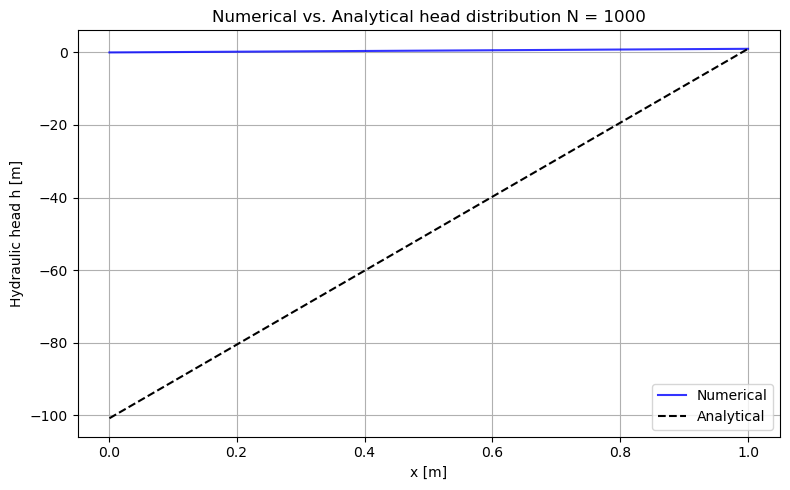

In [92]:
#plot hydraulic-head distribution with the analytical solution 1000 version
h_num1000 = np.linalg.solve(Tmatrix1000, b1000)

x_centres = (np.arange(1, N1000 + 1)) * dx1000
h_ana = h_R - (u_in / K) * (1.0 - x_centres)

plt.figure(figsize=(8,5))
plt.plot(x_centres, h_num1000, 'b-', alpha=0.8, label='Numerical')
plt.plot(x_centres, h_ana, 'k--', label='Analytical')
plt.xlabel('x [m]')
plt.ylabel('Hydraulic head h [m]')
plt.title('Numerical vs. Analytical head distribution N = 1000')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()